# Mortgage Default Risk Prediction

Predicting loan default risk from application-time data using the Home Credit Default Risk dataset.

## Problem Framing

Lenders need to assess the risk of default *before* a loan is approved, using only the information available at application time. This project builds and compares three models — logistic regression, XGBoost, and a neural network — to predict whether an applicant will default, and evaluates them using metrics appropriate for a highly imbalanced target rather than plain accuracy.

**Why this is a real problem, not just a classification exercise:** only 8.1% of applicants in this dataset default. A model that predicts "no default" for every applicant would be 91.9% accurate and completely useless. The core technical challenge here isn't fitting a model — it's building one that's actually evaluated and optimized for the minority class that matters.

## Dataset

- **Source:** [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle)
- **Table used:** `application_train.csv`
- **Size:** 307,511 applicants × 122 raw columns
- **Target:** `TARGET` — 1 if the applicant defaulted, 0 otherwise
- **Class balance:** 91.9% repaid / 8.1% defaulted

The dataset also includes auxiliary tables (`bureau.csv`, `previous_application.csv`, `installments_payments.csv`, etc.) which were **not used** in this iteration — see Limitations.

## Approach

### 1. Exploratory Data Analysis

- **Missingness:** 67 of 122 columns had missing values. Property/building descriptor columns (`COMMONAREA_*`, `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, `YEARS_BUILD_*`, etc.) were missing together at ~60–70% — evidence they represent one underlying theme (verifiable property records) rather than 30+ independent signals.
- **`OWN_CAR_AGE`:** missing in 66% of rows, but confirmed to be missing *exactly* when `FLAG_OWN_CAR = 'N'` — i.e., missing means "does not own a car," not "unknown."
- **Missingness as a signal:** applicants who defaulted had a higher median count of missing fields (48 vs. 34) than those who repaid — a candidate feature in its own right.
- **`DAYS_EMPLOYED` data bug:** the column contained a sentinel value of `365243` (≈1,000 years) in 55,374 rows (18% of the dataset) — 99.96% of them `NAME_INCOME_TYPE = 'Pensioner'`. This group has a materially *lower* default rate (5.4% vs. 8.7% for everyone else), confirming the anomaly is informative, not junk. It was replaced with `NaN` and preserved as a separate `DAYS_EMPLOYED_ANOMALY` flag.
- **Strongest numeric predictors:** `EXT_SOURCE_1/2/3` (external credit-bureau-style scores) showed the clearest separation between classes of any raw feature (e.g., `EXT_SOURCE_3` median: 0.546 for repaid vs. 0.379 for defaulted).
- **Categorical signal:** default rate fell monotonically with education level (10.9% for "Lower secondary" down to 1.8% for "Academic degree"), and varied meaningfully by occupation (17.2% for Low-skill Laborers vs. 4.8% for Accountants) — with a caution that small categories (n < ~500) produce unreliable rate estimates.

### 2. Feature Engineering

| Feature(s) | Reasoning |
|---|---|
| `DAYS_EMPLOYED_ANOMALY` + cleaned `DAYS_EMPLOYED` | Isolates the sentinel-value bug found in EDA while preserving its predictive signal |
| `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `CREDIT_ANNUITY_RATIO` | Loan burden relative to income, not absolute amounts |
| `AGE_YEARS`, `YEARS_EMPLOYED`, `EMPLOYED_AGE_RATIO` | Interpretable units; employment tenure relative to age |
| `OWN_CAR_AGE` filled with 0 | Missing = no car owned, not an unknown value — mean/median imputation would have been wrong |
| `PROPERTY_INFO_COUNT` + retained `_AVG` columns (dropped `_MODE`/`_MEDI`) | Collapsed 47 highly redundant, jointly-missing property columns into one count feature plus a non-redundant representative subset, after confirming the count carries real signal (20.0 vs. 17.0 mean fields provided, repaid vs. defaulted) |
| `EXT_SOURCE_MEAN`, `EXT_SOURCE_STD`, `EXT_SOURCE_COUNT` | Combined signal from the three strongest predictors; `STD` captures disagreement between sources; `COUNT` documents how many of the three were actually available per applicant (only 35.6% of applicants have all three) |
| `CREDIT_GOODS_RATIO` (replacing `AMT_GOODS_PRICE`) | `AMT_GOODS_PRICE` and `AMT_CREDIT` were found to be severely collinear (r = 0.987), producing unstable, opposite-signed coefficients in logistic regression; replaced with a ratio |
| Rare-category bucketing (`ORGANIZATION_TYPE`, threshold < 500 samples → `"Other"`) | Small categories (some with fewer than 20 samples) were found to produce inflated, overfit coefficients in the linear model |

### 3. Train / Validation / Test Split

Stratified 70/15/15 split on `TARGET`, preserving the 8.07% default rate identically across all three sets (train: 215,257 rows, val/test: 46,127 rows each).

### 4. Models

| Model | Key configuration |
|---|---|
| Logistic Regression | `class_weight='balanced'`, median imputation, standard scaling, one-hot encoding |
| XGBoost | `scale_pos_weight ≈ 11.4`, `max_depth=5`, `learning_rate=0.05`, early stopping on validation PR-AUC |
| PyTorch MLP | 2 hidden layers (128 → 64), BatchNorm + Dropout(0.3), `BCEWithLogitsLoss` with `pos_weight`, best-epoch checkpointing |

### 5. Evaluation Metric

**AUC-ROC and Precision-Recall AUC (PR-AUC)** — not accuracy, given the 8.1% base rate. PR-AUC in particular is reported relative to the random-classifier baseline (~0.081, matching the default rate), since raw PR-AUC values are not interpretable on their own with this level of imbalance.

## Results

| Model | AUC-ROC | PR-AUC | PR-AUC vs. random baseline |
|---|---|---|---|
| Logistic Regression | 0.7503 | 0.2369 | ~2.9x |
| **XGBoost** | **0.7629** | **0.2534** | **~3.1x** |
| Neural Net (MLP, best epoch) | 0.7522 | 0.2455 | ~3.0x |

**XGBoost was the best-performing model on both metrics.** The MLP required explicit early-stopping/checkpointing to avoid overfitting (validation performance peaked around epoch 5–8 and degraded afterward while training loss kept improving) and still didn't surpass XGBoost even at its best epoch. This is consistent with the broader pattern that gradient-boosted trees tend to outperform neural networks on structured/tabular data with a mix of numeric and high-cardinality categorical features.

### Feature Importance (XGBoost)

The top predictors were, in order: `EXT_SOURCE_MEAN`, `EXT_SOURCE_COUNT`, education level (Higher education), `CODE_GENDER`, `FLAG_OWN_CAR`, `YEARS_EMPLOYED`, and the engineered `CREDIT_GOODS_RATIO` / `CREDIT_ANNUITY_RATIO` ratios. This is consistent across three independent checks — EDA correlations, logistic regression coefficients, and XGBoost feature importance all agree that external credit scores dominate.

**Fairness flag:** `CODE_GENDER` appeared in the top 5 most important features. In many jurisdictions, using gender directly in credit decisions is legally restricted under fair-lending regulations, and even where it isn't, using it uncritically risks encoding societal bias rather than genuine risk signal the model can't distinguish between the two. This project retains gender for analysis and transparency, but flags it explicitly as something a production model would need to remove and/or audit for disparate impact before deployment.

## Limitations

- **Single-table model.** Only `application_train.csv` was used. The auxiliary tables (credit bureau history, previous Home Credit loans, installment payment behavior) almost certainly contain additional signal — top solutions on this dataset that incorporate those tables report meaningfully higher AUC-ROC (~0.78–0.80) than achieved here.
- **Partial external scores.** Only 35.6% of applicants have all three `EXT_SOURCE` values; the rest are computed from 1–2 sources (or none, for 172 rows), meaning `EXT_SOURCE_MEAN` isn't computed identically across all applicants.
- **Unreliable rates for small categories.** Several categorical levels (e.g., certain `NAME_INCOME_TYPE` and `ORGANIZATION_TYPE` values) have too few samples for their observed default rates to be trusted; these were bucketed for modeling but the underlying uncertainty remains.
- **Fairness not audited.** `CODE_GENDER` was retained as a feature and ranks among the most important; no disparate-impact or fairness audit was performed on model outputs across gender or other protected attributes.
- **No SHAP/local explainability included in this iteration.** Feature importance is reported at the global level (XGBoost gain) only.
- **No hyperparameter tuning.** All three models used reasonable defaults rather than a tuned search (e.g., grid/random/Bayesian search over XGBoost depth, learning rate, regularization).

```

In [100]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Importing Dataset

In [101]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/home-credit-default-risk/application_train.csv'

try:
    df = pd.read_csv(file_path)
    print('Data successfully loaded from Google Drive:')
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your Google Drive.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Data successfully loaded from Google Drive:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


sanity checks

In [102]:
print(df.shape)
print(df['TARGET'].value_counts(normalize=True))
print(df.dtypes.value_counts())

(307511, 122)
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
float64    65
int64      41
object     16
Name: count, dtype: int64


In [103]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)} out of {df.shape[1]}")
print(missing.head(20))

Columns with missing values: 67 out of 122
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
dtype: float64


In [104]:
pd.crosstab(df['FLAG_OWN_CAR'], df['OWN_CAR_AGE'].isnull())

OWN_CAR_AGE,False,True
FLAG_OWN_CAR,,
N,0,202924
Y,104582,5


In [105]:
df['missing_count'] = df.isnull().sum(axis=1)

df.groupby('TARGET')['missing_count'].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.0,29.496473,20.924935,0.0,5.0,34.0,49.0,61.0
1,24825.0,32.798590,20.614290,0.0,9.0,48.0,49.0,60.0


In [106]:
cols_to_check = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                  'DAYS_BIRTH', 'DAYS_EMPLOYED',
                  'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

df.groupby('TARGET')[cols_to_check].median()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
TARGET,,,,,,,,
0,0.517452,0.573905,0.546023,-15877.0,-1235.0,148500.0,517788.0,24876.0
1,0.361675,0.440381,0.379100,-14282.0,-1034.0,135000.0,497520.0,25263.0


In [107]:
df['DAYS_EMPLOYED'].describe()

,DAYS_EMPLOYED
count,307511.000000
mean,63815.045904
std,141275.766519
min,-17912.000000
25%,-2760.000000
50%,-1213.000000
75%,-289.000000
max,365243.000000


In [108]:
anomaly = df['DAYS_EMPLOYED'] == 365243
print(f"Count of anomaly: {anomaly.sum()}")
print(df.loc[anomaly, 'NAME_INCOME_TYPE'].value_counts())
print(df.groupby(anomaly)['TARGET'].mean())

Count of anomaly: 55374
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64
DAYS_EMPLOYED
False    0.086600
True     0.053996
Name: TARGET, dtype: float64


In [109]:
cat_cols = ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE']

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['TARGET'].agg(['mean', 'count']).sort_values('mean', ascending=False))


--- NAME_EDUCATION_TYPE ---
                                   mean   count
NAME_EDUCATION_TYPE                            
Lower secondary                0.109277    3816
Secondary / secondary special  0.089399  218391
Incomplete higher              0.084850   10277
Higher education               0.053551   74863
Academic degree                0.018293     164

--- NAME_FAMILY_STATUS ---
                          mean   count
NAME_FAMILY_STATUS                    
Civil marriage        0.099446   29775
Single / not married  0.098077   45444
Separated             0.081942   19770
Married               0.075599  196432
Widow                 0.058242   16088
Unknown               0.000000       2

--- NAME_INCOME_TYPE ---
                          mean   count
NAME_INCOME_TYPE                      
Maternity leave       0.400000       5
Unemployed            0.363636      22
Working               0.095885  158774
Commercial associate  0.074843   71617
State servant         0.057550   21

In [110]:
import numpy as np
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
print(df['DAYS_EMPLOYED_ANOMALY'].sum())
print(df['DAYS_EMPLOYED'].isnull().sum())

55374
55374


In [111]:
# Credit-to-income: how large is the loan relative to what they earn?
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# Annuity-to-income: what fraction of income goes to loan payments? (debt burden)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Credit-to-annuity: implied loan length in "annuity units" - longer implied term can mean higher risk
df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']

# Age in years (more interpretable than DAYS_BIRTH, and easier to reason about/explain)
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365

# Years employed (only meaningful now that we've cleaned the anomaly)
df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365

# Employment tenure as a fraction of age - a 25-year-old with 5 years employed is very different from a 50-year-old with 5 years employed
df['EMPLOYED_AGE_RATIO'] = df['YEARS_EMPLOYED'] / df['AGE_YEARS']

In [112]:
new_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO',
            'AGE_YEARS', 'YEARS_EMPLOYED', 'EMPLOYED_AGE_RATIO']
df[new_cols].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_ANNUITY_RATIO,AGE_YEARS,YEARS_EMPLOYED,EMPLOYED_AGE_RATIO
count,307511.000000,307499.000000,307499.000000,307511.000000,252137.000000,252137.000000
mean,3.957570,0.180930,21.612322,43.936973,6.531971,0.156861
std,2.689728,0.094574,7.823823,11.956133,6.406466,0.133549
min,0.004808,0.000224,8.036674,20.517808,-0.000000,-0.000000
25%,2.018667,0.114782,15.614496,34.008219,2.101370,0.056099
50%,3.265067,0.162833,20.000000,43.150685,4.515068,0.118733
75%,5.159880,0.229067,27.099985,53.923288,8.698630,0.219170
max,84.736842,1.875965,45.305079,69.120548,49.073973,0.728811


In [113]:
# OWN_CAR_AGE: missing = doesn't own a car, so 0 is the correct fill (not mean/median)
df['OWN_CAR_AGE'] = df['OWN_CAR_AGE'].fillna(0)

# Property block: rather than imputing 30+ near-duplicate columns individually,
# collapse into a count of how many property details were actually provided.
property_cols = [c for c in df.columns if c.endswith(('_AVG', '_MODE', '_MEDI'))]
df['PROPERTY_INFO_COUNT'] = df[property_cols].notnull().sum(axis=1)

print(f"Property columns collapsed: {len(property_cols)}")
print(df['PROPERTY_INFO_COUNT'].describe())

Property columns collapsed: 47
count    307511.000000
mean         19.803057
std          20.690048
min           0.000000
25%           0.000000
50%          14.000000
75%          47.000000
max          47.000000
Name: PROPERTY_INFO_COUNT, dtype: float64


In [114]:
df.groupby('TARGET')['PROPERTY_INFO_COUNT'].mean()

,PROPERTY_INFO_COUNT
TARGET,
0,20.047310
1,17.021712


In [115]:
# Also check one representative property value directly
df.groupby('TARGET')['LIVINGAREA_AVG'].median()

,LIVINGAREA_AVG
TARGET,
0,0.0752
1,0.0667


In [116]:
mode_medi_cols = [c for c in df.columns if c.endswith(('_MODE', '_MEDI'))]
df = df.drop(columns=mode_medi_cols)

print(f"Dropped {len(mode_medi_cols)} redundant columns")
print(f"New shape: {df.shape}")

Dropped 33 redundant columns
New shape: (307511, 98)


In [117]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

# Combined signal - average external score
df['EXT_SOURCE_MEAN'] = df[ext_cols].mean(axis=1)

# Spread across the three - do the sources agree or disagree?
df['EXT_SOURCE_STD'] = df[ext_cols].std(axis=1)

# How many of the three are actually present
df['EXT_SOURCE_COUNT'] = df[ext_cols].notnull().sum(axis=1)

print(df.groupby('TARGET')[['EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'EXT_SOURCE_COUNT']].mean())

        EXT_SOURCE_MEAN  EXT_SOURCE_STD  EXT_SOURCE_COUNT
TARGET                                                   
0              0.519109        0.149857          2.241197
1              0.397003        0.167606          2.174220


In [118]:
df['EXT_SOURCE_COUNT'].value_counts().sort_index()

,count
EXT_SOURCE_COUNT,
0,172
1,36737
2,161013
3,109589


In [119]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df['TARGET']

# First split: 70% train, 30% temp (which becomes val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: split temp 50/50 into val and test (15%/15% of original)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train target rate: {y_train.mean():.4f}")
print(f"Val target rate: {y_val.mean():.4f}")
print(f"Test target rate: {y_test.mean():.4f}")

Train: (215257, 99), Val: (46127, 99), Test: (46127, 99)
Train target rate: 0.0807
Val target rate: 0.0807
Test target rate: 0.0807


In [120]:
print("Object dtype columns:", X_train.select_dtypes(include='object').columns.tolist())
print("\nColumns with missing values in X_train:", X_train.isnull().sum()[X_train.isnull().sum() > 0].shape[0])

Object dtype columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

Columns with missing values in X_train: 40


In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = X_train.select_dtypes(exclude='object').columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [122]:
from sklearn.linear_model import LogisticRegression

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',  # upweights the minority (default) class automatically
        max_iter=1000,
        random_state=42
    ))
])

full_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'AMT_CREDIT', 'AMT_ANNUITY',
                                                   'AMT_GOODS_PRICE',
                                                   'REGION_POPULATION_RELATIVE',
                                                   'DAYS_BIRTH',
                                                   'DAYS_EMPLOYED',
                                                   'DAYS_REGISTRATION',
                                                   'DAYS_ID_PUBLISH',
                                                   'OWN_CAR_AGE...
                                                                                 sparse_output=False))]),
                                                  ['NAME_CONTRACT_TYPE',
                                                   'CODE_GENDER',
                                                   'FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'NAME_TYPE_SUITE',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE',
                                                   'WEEKDAY_APPR_PROCESS_START',
                                                   'ORGANIZATION_TYPE'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [123]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_proba = full_pipeline.predict_proba(X_val)[:, 1]

auc_roc = roc_auc_score(y_val, val_proba)
pr_auc = average_precision_score(y_val, val_proba)

print(f"Validation AUC-ROC: {auc_roc:.4f}")
print(f"Validation PR-AUC: {pr_auc:.4f}")

Validation AUC-ROC: 0.7499
Validation PR-AUC: 0.2355


In [124]:
feature_names = (numeric_cols +
    full_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_cols).tolist())

coefs = full_pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df.sort_values('abs_coef', ascending=False).head(15)

,feature,coefficient,abs_coef
4,AMT_GOODS_PRICE,-0.917860,0.917860
189,ORGANIZATION_TYPE_Realtor,0.867549,0.867549
2,AMT_CREDIT,0.839800,0.839800
182,ORGANIZATION_TYPE_Legal Services,0.827004,0.827004
111,NAME_EDUCATION_TYPE_Academic degree,-0.784347,0.784347
106,NAME_INCOME_TYPE_Pensioner,-0.612726,0.612726
207,ORGANIZATION_TYPE_Transport: type 3,0.515915,0.515915
109,NAME_INCOME_TYPE_Unemployed,0.492544,0.492544
184,ORGANIZATION_TYPE_Military,-0.461449,0.461449
203,ORGANIZATION_TYPE_Trade: type 6,-0.457006,0.457006


In [125]:
X_train['ORGANIZATION_TYPE'].value_counts().tail(15)

,count
ORGANIZATION_TYPE,
Realtor,279
Culture,269
Industry: type 12,258
Trade: type 1,237
Legal Services,218
Mobile,211
Cleaning,195
Transport: type 1,145
Industry: type 6,77


In [126]:
ext_check = coef_df[coef_df['feature'].str.contains('EXT_SOURCE')]
print(ext_check)

             feature  coefficient  abs_coef
27      EXT_SOURCE_1    -0.141605  0.141605
28      EXT_SOURCE_2    -0.262362  0.262362
29      EXT_SOURCE_3    -0.406203  0.406203
84   EXT_SOURCE_MEAN    -0.170713  0.170713
85    EXT_SOURCE_STD     0.034459  0.034459
86  EXT_SOURCE_COUNT    -0.089624  0.089624


In [127]:
def bucket_rare_categories(df_train, df_val, df_test, cols, threshold=500):
    """Fit rare-category buckets on train, apply same buckets to val/test."""
    df_train = df_train.copy()
    df_val = df_val.copy()
    df_test = df_test.copy()

    for col in cols:
        counts = df_train[col].value_counts()
        rare_categories = counts[counts < threshold].index

        df_train[col] = df_train[col].replace(rare_categories, 'Other')
        df_val[col] = df_val[col].replace(rare_categories, 'Other')
        df_test[col] = df_test[col].replace(rare_categories, 'Other')

    return df_train, df_val, df_test

X_train, X_val, X_test = bucket_rare_categories(
    X_train, X_val, X_test, categorical_cols, threshold=500
)

print(X_train['ORGANIZATION_TYPE'].value_counts().tail(10))

ORGANIZATION_TYPE
Trade: type 2        1338
Restaurant           1285
Services             1089
University            917
Industry: type 7      903
Transport: type 3     851
Industry: type 1      737
Hotel                 686
Electricity           674
Industry: type 4      633
Name: count, dtype: int64


In [128]:
full_pipeline.fit(X_train, y_train)

val_proba = full_pipeline.predict_proba(X_val)[:, 1]
print(f"Validation AUC-ROC: {roc_auc_score(y_val, val_proba):.4f}")
print(f"Validation PR-AUC: {average_precision_score(y_val, val_proba):.4f}")

Validation AUC-ROC: 0.7503
Validation PR-AUC: 0.2354


In [129]:
feature_names = (numeric_cols +
    full_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(categorical_cols).tolist())

coefs = full_pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df.sort_values('abs_coef', ascending=False).head(15)

,feature,coefficient,abs_coef
4,AMT_GOODS_PRICE,-0.909639,0.909639
2,AMT_CREDIT,0.820660,0.820660
181,ORGANIZATION_TYPE_Transport: type 3,0.610734,0.610734
75,missing_count,0.470606,0.470606
167,ORGANIZATION_TYPE_Military,-0.456144,0.456144
83,PROPERTY_INFO_COUNT,0.449230,0.449230
177,ORGANIZATION_TYPE_Trade: type 2,-0.430951,0.430951
29,EXT_SOURCE_3,-0.408376,0.408376
154,ORGANIZATION_TYPE_Construction,0.345389,0.345389
174,ORGANIZATION_TYPE_Security Ministries,-0.307290,0.307290


In [130]:
X_train['ORGANIZATION_TYPE'].value_counts()[['Transport: type 3', 'Trade: type 2']]

,count
ORGANIZATION_TYPE,
Transport: type 3,851
Trade: type 2,1338


In [131]:
X_train[['AMT_GOODS_PRICE', 'AMT_CREDIT']].corr()

,AMT_GOODS_PRICE,AMT_CREDIT
AMT_GOODS_PRICE,1.000000,0.986993
AMT_CREDIT,0.986993,1.000000


In [132]:
# Keep AMT_CREDIT (the actual loan amount - what we're assessing risk on)
# Drop AMT_GOODS_PRICE, but preserve the info as a ratio - are they financing more than the goods are worth?
X_train['CREDIT_GOODS_RATIO'] = X_train['AMT_CREDIT'] / X_train['AMT_GOODS_PRICE']
X_val['CREDIT_GOODS_RATIO'] = X_val['AMT_CREDIT'] / X_val['AMT_GOODS_PRICE']
X_test['CREDIT_GOODS_RATIO'] = X_test['AMT_CREDIT'] / X_test['AMT_GOODS_PRICE']

X_train = X_train.drop(columns=['AMT_GOODS_PRICE'])
X_val = X_val.drop(columns=['AMT_GOODS_PRICE'])
X_test = X_test.drop(columns=['AMT_GOODS_PRICE'])

numeric_cols = [c for c in numeric_cols if c != 'AMT_GOODS_PRICE'] + ['CREDIT_GOODS_RATIO']

In [133]:
# Rebuild preprocessor with updated numeric_cols (AMT_GOODS_PRICE removed, CREDIT_GOODS_RATIO added)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

full_pipeline.fit(X_train, y_train)

val_proba = full_pipeline.predict_proba(X_val)[:, 1]
print(f"Validation AUC-ROC: {roc_auc_score(y_val, val_proba):.4f}")
print(f"Validation PR-AUC: {average_precision_score(y_val, val_proba):.4f}")

Validation AUC-ROC: 0.7503
Validation PR-AUC: 0.2369


In [134]:
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 11.39


In [135]:
from sklearn.preprocessing import OneHotEncoder

# Encode categoricals only - no scaling, no imputation needed for numeric
cat_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_encoder.fit(X_train[categorical_cols])

def encode_for_xgb(X):
    cat_encoded = cat_encoder.transform(X[categorical_cols])
    cat_df = pd.DataFrame(cat_encoded, columns=cat_encoder.get_feature_names_out(categorical_cols), index=X.index)
    return pd.concat([X[numeric_cols], cat_df], axis=1)

X_train_xgb = encode_for_xgb(X_train)
X_val_xgb = encode_for_xgb(X_val)
X_test_xgb = encode_for_xgb(X_test)

print(X_train_xgb.shape, X_val_xgb.shape, X_test_xgb.shape)

(215257, 187) (46127, 187) (46127, 187)


In [136]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=20,
    random_state=42
)

xgb_model.fit(
    X_train_xgb, y_train,
    eval_set=[(X_val_xgb, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.19544
[50]	validation_0-aucpr:0.22923
[100]	validation_0-aucpr:0.24211
[150]	validation_0-aucpr:0.24751
[200]	validation_0-aucpr:0.25028
[250]	validation_0-aucpr:0.25275
[299]	validation_0-aucpr:0.25325


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=20,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [137]:
from sklearn.metrics import roc_auc_score, average_precision_score

val_proba_xgb = xgb_model.predict_proba(X_val_xgb)[:, 1]

auc_roc_xgb = roc_auc_score(y_val, val_proba_xgb)
pr_auc_xgb = average_precision_score(y_val, val_proba_xgb)

print(f"XGBoost Validation AUC-ROC: {auc_roc_xgb:.4f}")
print(f"XGBoost Validation PR-AUC: {pr_auc_xgb:.4f}")

XGBoost Validation AUC-ROC: 0.7629
XGBoost Validation PR-AUC: 0.2534


In [138]:
importance_df = pd.DataFrame({
    'feature': X_train_xgb.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(15)

,feature,importance
83,EXT_SOURCE_MEAN,0.108892
85,EXT_SOURCE_COUNT,0.028299
109,NAME_EDUCATION_TYPE_Higher education,0.026094
90,CODE_GENDER_M,0.019024
89,CODE_GENDER_F,0.016461
92,FLAG_OWN_CAR_N,0.016435
80,YEARS_EMPLOYED,0.015272
86,CREDIT_GOODS_RATIO,0.014855
49,FLAG_DOCUMENT_3,0.013060
87,NAME_CONTRACT_TYPE_Cash loans,0.012647


In [139]:
mlp_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])

X_train_mlp = mlp_preprocessor.fit_transform(X_train)
X_val_mlp = mlp_preprocessor.transform(X_val)
X_test_mlp = mlp_preprocessor.transform(X_test)

print(X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape)

(215257, 185) (46127, 185) (46127, 185)


In [140]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train_mlp, y_train)
val_dataset = TabularDataset(X_val_mlp, y_val)
test_dataset = TabularDataset(X_test_mlp, y_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

Using device: cpu


In [141]:
class DefaultRiskMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 1)  # raw logit output - no sigmoid here
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_mlp.shape[1]
model = DefaultRiskMLP(input_dim).to(device)
print(model)

DefaultRiskMLP(
  (network): Sequential(
    (0): Linear(in_features=185, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [142]:
from sklearn.metrics import roc_auc_score, average_precision_score

pos_weight = torch.tensor([scale_pos_weight], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 15

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_dataset)

    # Validation
    model.eval()
    val_logits_all, val_y_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            val_logits_all.append(logits.cpu())
            val_y_all.append(y_batch)

    val_logits_all = torch.cat(val_logits_all).numpy().flatten()
    val_y_all = torch.cat(val_y_all).numpy().flatten()
    val_proba = 1 / (1 + np.exp(-val_logits_all))  # manual sigmoid since we output raw logits

    val_auc = roc_auc_score(val_y_all, val_proba)
    val_pr_auc = average_precision_score(val_y_all, val_proba)

    print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {train_loss:.4f} | Val AUC-ROC: {val_auc:.4f} | Val PR-AUC: {val_pr_auc:.4f}")

Epoch 1/15 | Train Loss: 1.1248 | Val AUC-ROC: 0.7499 | Val PR-AUC: 0.2339
Epoch 2/15 | Train Loss: 1.0932 | Val AUC-ROC: 0.7522 | Val PR-AUC: 0.2363
Epoch 3/15 | Train Loss: 1.0849 | Val AUC-ROC: 0.7525 | Val PR-AUC: 0.2372
Epoch 4/15 | Train Loss: 1.0799 | Val AUC-ROC: 0.7527 | Val PR-AUC: 0.2396
Epoch 5/15 | Train Loss: 1.0747 | Val AUC-ROC: 0.7535 | Val PR-AUC: 0.2423
Epoch 6/15 | Train Loss: 1.0704 | Val AUC-ROC: 0.7531 | Val PR-AUC: 0.2409
Epoch 7/15 | Train Loss: 1.0653 | Val AUC-ROC: 0.7532 | Val PR-AUC: 0.2403
Epoch 8/15 | Train Loss: 1.0608 | Val AUC-ROC: 0.7514 | Val PR-AUC: 0.2391
Epoch 9/15 | Train Loss: 1.0536 | Val AUC-ROC: 0.7507 | Val PR-AUC: 0.2409
Epoch 10/15 | Train Loss: 1.0508 | Val AUC-ROC: 0.7505 | Val PR-AUC: 0.2407
Epoch 11/15 | Train Loss: 1.0442 | Val AUC-ROC: 0.7504 | Val PR-AUC: 0.2403
Epoch 12/15 | Train Loss: 1.0402 | Val AUC-ROC: 0.7503 | Val PR-AUC: 0.2406
Epoch 13/15 | Train Loss: 1.0346 | Val AUC-ROC: 0.7486 | Val PR-AUC: 0.2396
Epoch 14/15 | Train L

In [143]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

INK = "#16202E"
MUTED = "#6B7686"
GOLD = "#D9A54A"
GREEN = "#3E8E6E"
RED = "#B84A3A"
GRID = "#E5E8EC"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def clean_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

Chart 1 — Class imbalance

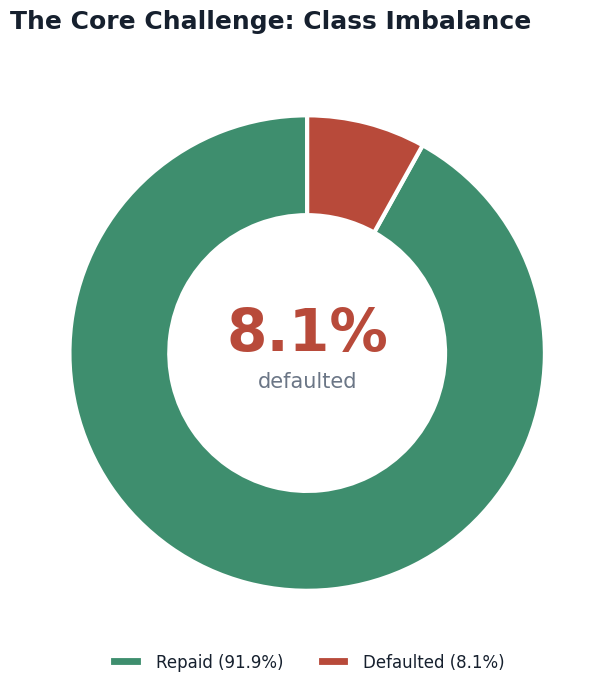

In [152]:
fig, ax = plt.subplots(figsize=(7, 7))
sizes = [df['TARGET'].value_counts(normalize=True)[0], df['TARGET'].value_counts(normalize=True)[1]]
labels = ['Repaid', 'Defaulted']
colors = [GREEN, RED]

wedges, _ = ax.pie(sizes, colors=colors, startangle=90, wedgeprops=dict(width=0.42, edgecolor='white', linewidth=3))
ax.text(0, 0.08, f"{sizes[1]*100:.1f}%", ha='center', va='center', fontsize=42, fontweight='bold', color=RED)
ax.text(0, -0.12, "defaulted", ha='center', va='center', fontsize=15, color=MUTED)

ax.legend(wedges, [f"{l} ({s*100:.1f}%)" for l, s in zip(labels, sizes)],
          loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False, fontsize=12)
ax.set_title("The Core Challenge: Class Imbalance", fontsize=18, fontweight='bold', pad=20, loc='left')
plt.tight_layout()
plt.savefig('/content/01_class_imbalance.png', dpi=200, bbox_inches='tight')
plt.show()

Chart 2 — Missingness (top columns, deduplicated by underlying attribute)

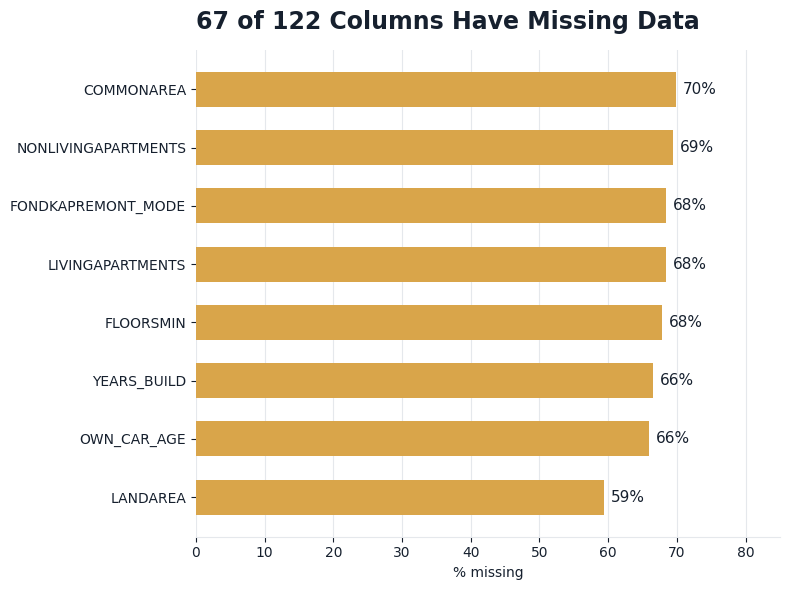

In [153]:
missing_attrs = {
    'COMMONAREA': df['COMMONAREA_AVG'].isnull().mean(),
    'NONLIVINGAPARTMENTS': df['NONLIVINGAPARTMENTS_AVG'].isnull().mean(),
    'FONDKAPREMONT_MODE': 0.683862,  # dropped column - value from original EDA
    'LIVINGAPARTMENTS': df['LIVINGAPARTMENTS_AVG'].isnull().mean(),
    'FLOORSMIN': df['FLOORSMIN_AVG'].isnull().mean(),
    'YEARS_BUILD': df['YEARS_BUILD_AVG'].isnull().mean(),
    'OWN_CAR_AGE': 0.659908,  # already filled with 0 in your pipeline, so also hardcoded
    'LANDAREA': df['LANDAREA_AVG'].isnull().mean(),
}
s = pd.Series(missing_attrs).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(s.index, s.values * 100, color=GOLD, zorder=3, height=0.6)
for bar, val in zip(bars, s.values):
    ax.text(val*100 + 1, bar.get_y() + bar.get_height()/2, f"{val*100:.0f}%", va='center', fontsize=11, color=INK)
clean_ax(ax)
ax.set_xlim(0, 85)
ax.set_title("67 of 122 Columns Have Missing Data", fontsize=17, fontweight='bold', loc='left', pad=15)
ax.set_xlabel("% missing")
plt.tight_layout()
plt.savefig('/content/02_missingness.png', dpi=200, bbox_inches='tight')
plt.show()

Chart 3 — EXT_SOURCE scores by outcome

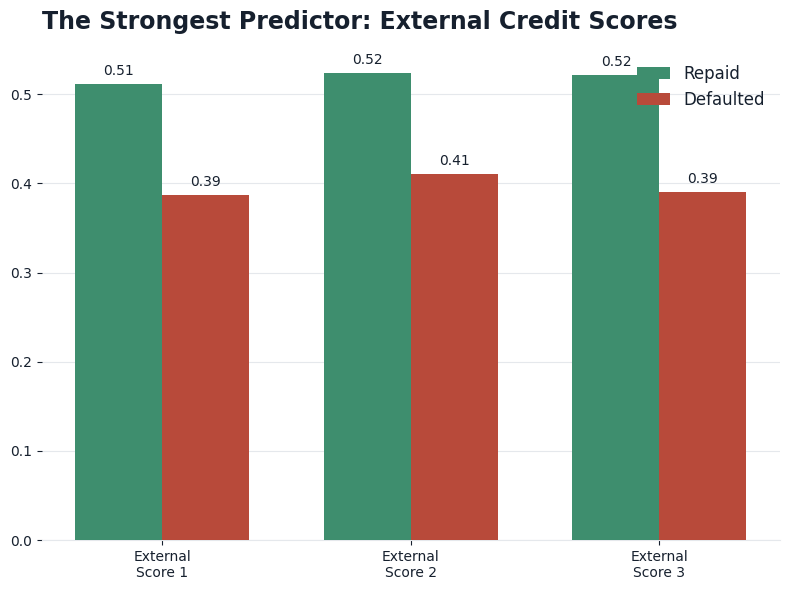

In [154]:
ext_means = df.groupby('TARGET')[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean()

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(3)
width = 0.35
b1 = ax.bar(x - width/2, ext_means.loc[0], width, label='Repaid', color=GREEN, zorder=3)
b2 = ax.bar(x + width/2, ext_means.loc[1], width, label='Defaulted', color=RED, zorder=3)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}", ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(['External\nScore 1', 'External\nScore 2', 'External\nScore 3'])
clean_ax(ax)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.grid(axis='x', visible=False)
ax.legend(frameon=False, fontsize=12)
ax.set_title("The Strongest Predictor: External Credit Scores", fontsize=17, fontweight='bold', loc='left', pad=15)
plt.tight_layout()
plt.savefig('/content/03_ext_source.png', dpi=200, bbox_inches='tight')
plt.show()

Chart 4 — The DAYS_EMPLOYED bug

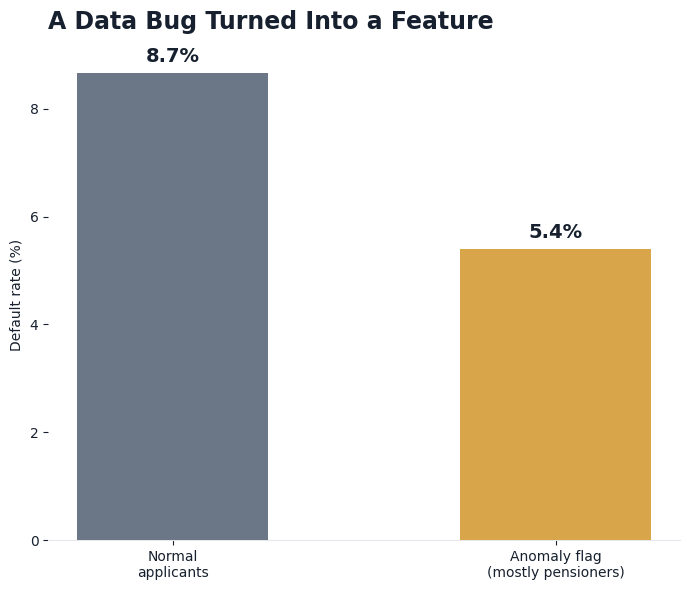

In [155]:
anomaly_rates = df.groupby('DAYS_EMPLOYED_ANOMALY')['TARGET'].mean() if 'DAYS_EMPLOYED_ANOMALY' in df.columns \
    else pd.Series({0: 0.0866, 1: 0.0540})

fig, ax = plt.subplots(figsize=(7, 6))
bars = ax.bar(['Normal\napplicants', 'Anomaly flag\n(mostly pensioners)'], anomaly_rates.values * 100,
               color=[MUTED, GOLD], width=0.5, zorder=3)
for bar, val in zip(bars, anomaly_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, val*100 + 0.2, f"{val*100:.1f}%", ha='center', fontsize=14, fontweight='bold')
clean_ax(ax)
ax.grid(axis='x', visible=False)
ax.set_ylabel("Default rate (%)")
ax.set_title("A Data Bug Turned Into a Feature", fontsize=17, fontweight='bold', loc='left', pad=15)
plt.tight_layout()
plt.savefig('/content/04_days_employed_bug.png', dpi=200, bbox_inches='tight')
plt.show()

Chart 5 — Default rate by education

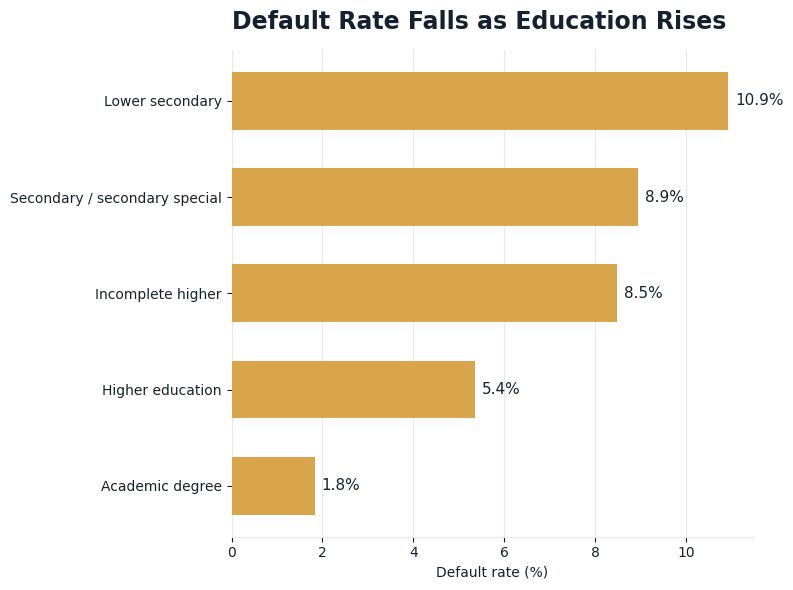

In [156]:
edu = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(edu.index, edu.values * 100, color=GOLD, zorder=3, height=0.6)
for bar, val in zip(bars, edu.values):
    ax.text(val*100 + 0.15, bar.get_y() + bar.get_height()/2, f"{val*100:.1f}%", va='center', fontsize=11)
clean_ax(ax)
ax.set_title("Default Rate Falls as Education Rises", fontsize=17, fontweight='bold', loc='left', pad=15)
ax.set_xlabel("Default rate (%)")
plt.tight_layout()
plt.savefig('/content/05_education.png', dpi=200, bbox_inches='tight')
plt.show()

Chart 6 — Model comparison

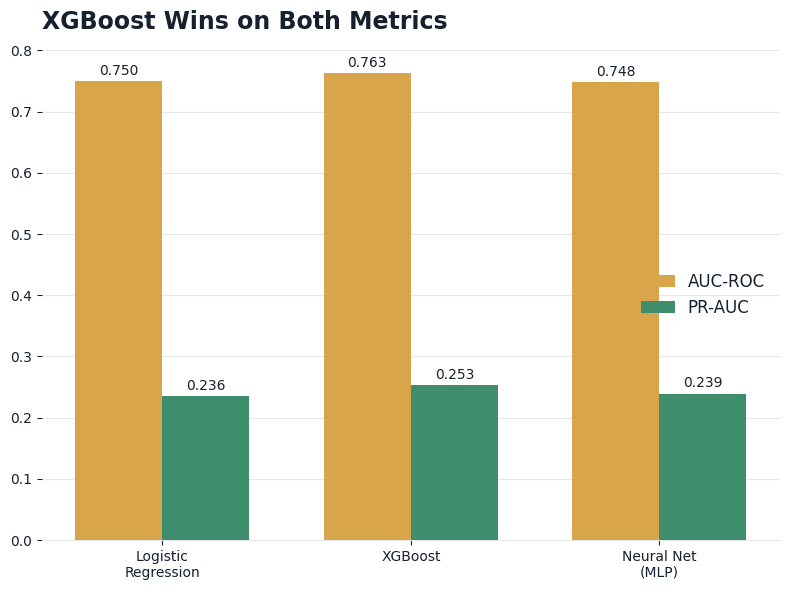

In [157]:
models = ['Logistic\nRegression', 'XGBoost', 'Neural Net\n(MLP)']
auc_roc_vals = [auc_roc, auc_roc_xgb, val_auc]      # use your actual variable names
pr_auc_vals = [pr_auc, pr_auc_xgb, val_pr_auc]       # adjust if named differently

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(3)
width = 0.35
b1 = ax.bar(x - width/2, auc_roc_vals, width, label='AUC-ROC', color=GOLD, zorder=3)
b2 = ax.bar(x + width/2, pr_auc_vals, width, label='PR-AUC', color=GREEN, zorder=3)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.3f}", ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(models)
clean_ax(ax)
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.grid(axis='x', visible=False)
ax.legend(frameon=False, fontsize=12)
ax.set_title("XGBoost Wins on Both Metrics", fontsize=17, fontweight='bold', loc='left', pad=15)
plt.tight_layout()
plt.savefig('/content/06_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

Chart 7 — XGBoost feature importance (top 12)

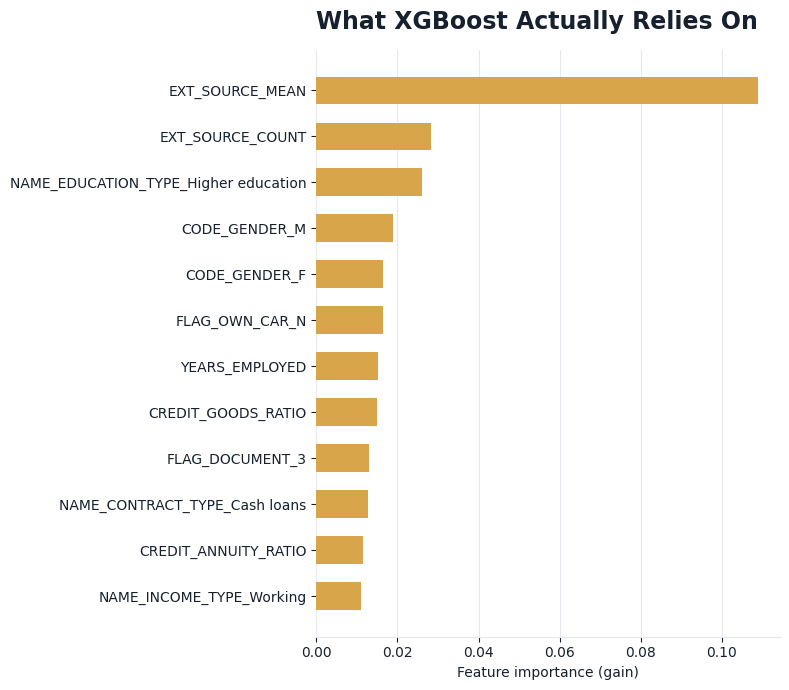

In [158]:
top_features = importance_df.head(12).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(top_features['feature'], top_features['importance'], color=GOLD, zorder=3, height=0.6)
clean_ax(ax)
ax.set_title("What XGBoost Actually Relies On", fontsize=17, fontweight='bold', loc='left', pad=15)
ax.set_xlabel("Feature importance (gain)")
plt.tight_layout()
plt.savefig('/content/07_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()